# Trainer Benchmark: Batch Size Sweeps

In [1]:
%matplotlib inline
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

BLUE = '#2a78d6'
ORANGE = '#eb6834'
GRAY = '#8a8a86'

In [2]:
batch_dir = Path('benchmark_trainer_out_batch_small')
replay_dir = Path('benchmark_trainer_out_replay_small')

batch_sweep = pd.read_csv(batch_dir / 'summary.csv')
replay_sweep = pd.read_csv(replay_dir / 'summary.csv')

for df in (batch_sweep, replay_sweep):
    df['structures_per_sec'] = df['n_train'] / df['sec_per_epoch']
    df['atoms_per_sec'] = df['n_atoms_train'] / df['sec_per_epoch']

batch_sweep

,batch_size,replay_batch_size,status,epochs_run,wall_clock_s,sec_per_epoch,peak_gpu_mb,final_valid_loss,n_train,n_atoms_train,peak_gpu_mb_train,peak_gpu_mb_valid,peak_gpu_mb_replay,reserved_gpu_mb_train,reserved_gpu_mb_valid,reserved_gpu_mb_replay,structures_per_sec,atoms_per_sec
0,2,2,ok,3,450.16,150.055,1506.5,0.000949,800,339200,3456.3,1638.3,1564.8,6113.2,6113.2,6113.2,5.331378,2260.504482
1,4,2,ok,3,440.78,146.927,1461.3,0.002190,800,339200,6313.7,2915.4,1654.3,15477.0,15477.0,15479.1,5.444881,2308.629455
2,8,2,ok,3,438.95,146.318,1602.4,0.007402,800,339200,11847.6,5342.7,1721.3,33881.6,33881.6,33881.6,5.467543,2318.238358
3,16,2,ok,3,438.67,146.225,1575.0,0.014772,800,339200,22881.0,10085.3,1668.2,69187.1,69187.1,69187.1,5.471021,2319.712771


In [3]:
import os

epoch_files = sorted(batch_dir.glob('bs*_epochs.csv'), key=os.path.getmtime)
for f in epoch_files:
    size = f.stat().st_size
    mtime = pd.Timestamp(f.stat().st_mtime, unit='s')
    print(f'{f.name:30s} {size:>6d} bytes   last written {mtime}')

completed_bs = set(batch_sweep['batch_size'])
attempted_bs = {int(f.stem.split('_')[0][2:]) for f in epoch_files}
incomplete_bs = sorted(attempted_bs - completed_bs)
fixed_replay_bs = int(batch_sweep['replay_batch_size'].iloc[0])
print(f'\ncompleted: {sorted(completed_bs)}')
print(f'attempted but no summary.csv row (died mid-candidate): {incomplete_bs}')
died_at_bs = incomplete_bs[0] if incomplete_bs else None

bs2_replay2_epochs.csv            998 bytes   last written 2026-08-11 19:13:58.038500309
bs4_replay2_epochs.csv           1000 bytes   last written 2026-08-11 19:21:19.037589550
bs8_replay2_epochs.csv           1001 bytes   last written 2026-08-11 19:28:37.900028229
bs16_replay2_epochs.csv           986 bytes   last written 2026-08-11 19:35:56.537616253
bs32_replay2_epochs.csv           752 bytes   last written 2026-08-11 19:41:05.253774643

completed: [2, 4, 8, 16]
attempted but no summary.csv row (died mid-candidate): [32]


In [4]:
if died_at_bs is not None:
    died_path = batch_dir / f'bs{died_at_bs}_replay{fixed_replay_bs}_epochs.csv'
    died_epochs = pd.read_csv(died_path)
    print(f'batch_size={died_at_bs} got through {len(died_epochs)} epoch(s) before dying:')
    died_epochs[['epoch', 'peak_gpu_mb_train', 'reserved_gpu_mb_train', 'total_loss_train', 'total_loss_valid']]

batch_size=32 got through 2 epoch(s) before dying:


In [5]:
candidate_line = f'batch_size={died_at_bs} replay_batch_size={fixed_replay_bs}: starting'
relevance_marker = 'Sweeping'  # only benchmark_trainer.py's own runs print this
slurm_logs = sorted(Path('.').glob('slurm-*.out'), key=os.path.getmtime)

relevant_log = next((log for log in reversed(slurm_logs) if relevance_marker in log.read_text(errors='replace')), None)

if relevant_log is not None:
    text = relevant_log.read_text(errors='replace')
    print(f'=== {relevant_log.name} ===')
    idx = text.find(candidate_line)
    if idx != -1:
        print(text[max(0, idx - 200):idx + 400])
    else:
        term_idx = text.rfind('\nTerminated\n')
        print(text[max(0, term_idx - 200):term_idx + 20] if term_idx != -1 else '(no "Terminated" line found)')

=== slurm-346.out ===
FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  return torch.load(BytesIO(model_msg), map_location='cpu')
Terminated
/home/mi


In [6]:
mtimes = [f.stat().st_mtime for f in epoch_files]
span_min = (max(mtimes) - min(mtimes)) / 60
smallest_bs = int(batch_sweep['batch_size'].min())
print(f'epoch-file mtimes span {span_min:.0f} min, '
      f'{pd.Timestamp(min(mtimes), unit="s")} -> {pd.Timestamp(max(mtimes), unit="s")}')
print('(this undercounts the true run length -- it starts at the first *completed* '
      f"epoch, not process launch -- but batch_size={smallest_bs}'s own run alone took "
      f"{batch_sweep.loc[batch_sweep.batch_size == smallest_bs, 'wall_clock_s'].item() / 60:.1f} min)")
if relevant_log is not None:
    print(f'{relevant_log.name}: {relevant_log.stat().st_size} bytes, '
          f'{len(relevant_log.read_text().splitlines())} lines total')

epoch-file mtimes span 27 min, 2026-08-11 19:13:58.038500309 -> 2026-08-11 19:41:05.253774643
(this undercounts the true run length -- it starts at the first *completed* epoch, not process launch -- but batch_size=2's own run alone took 7.5 min)
slurm-346.out: 10287 bytes, 79 lines total


peak_gpu_mb_train: scaling ~ batch_size^0.91, projected @ batch_size=32 = 42,363 MB (41.4 GB) vs actually observed (partial run) = 44,168 MB (43.1 GB)
reserved_gpu_mb_train: scaling ~ batch_size^1.16, projected @ batch_size=32 = 162,882 MB (159.1 GB) vs actually observed (partial run) = 102,377 MB (100.0 GB)


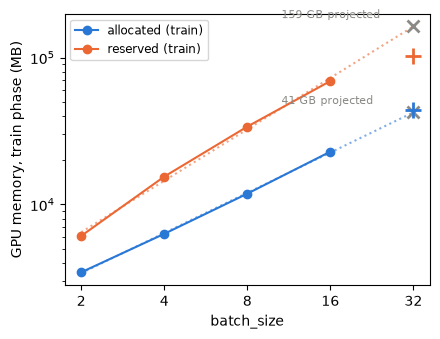

In [7]:
bs_known = batch_sweep['batch_size'].to_numpy(dtype=float)
mem_cols = ['peak_gpu_mb_train', 'reserved_gpu_mb_train']
fig, ax = plt.subplots(figsize=(4.5, 3.5))

bs_grid = np.geomspace(bs_known.min(), died_at_bs, 50)
for col, color, label in zip(mem_cols, [BLUE, ORANGE], ['allocated (train)', 'reserved (train)']):
    y_known = batch_sweep[col].to_numpy(dtype=float)
    slope, intercept = np.polyfit(np.log(bs_known), np.log(y_known), 1)
    pred = np.exp(np.polyval((slope, intercept), np.log(died_at_bs)))
    actual = died_epochs[col].max()  # real value observed before the crash, not extrapolated

    ax.plot(bs_known, y_known, marker='o', color=color, label=label)
    ax.plot(bs_grid, np.exp(np.polyval((slope, intercept), np.log(bs_grid))),
            color=color, linestyle=':', alpha=0.6)
    ax.plot(died_at_bs, pred, marker='x', color=GRAY, markersize=9, markeredgewidth=2, zorder=5)
    ax.plot(died_at_bs, actual, marker='+', color=color, markersize=11, markeredgewidth=2, zorder=5)
    ax.annotate(f'{pred / 1024:.0f} GB projected', (died_at_bs, pred),
                textcoords='offset points', xytext=(-95, 6), fontsize=8, color=GRAY)
    print(f'{col}: scaling ~ batch_size^{slope:.2f}, projected @ batch_size={died_at_bs} = '
          f'{pred:,.0f} MB ({pred/1024:.1f} GB) vs actually observed (partial run) = '
          f'{actual:,.0f} MB ({actual/1024:.1f} GB)')

ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_xticks(bs_known.tolist() + [died_at_bs])
ax.set_xticklabels([str(int(b)) for b in bs_known] + [str(died_at_bs)])
ax.set_xlabel('batch_size')
ax.set_ylabel('GPU memory, train phase (MB)')
ax.legend(fontsize='small')
fig.tight_layout()

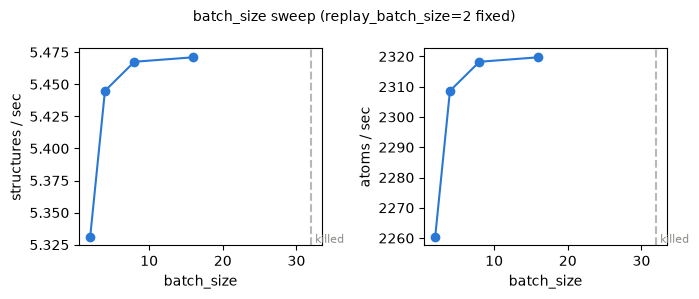

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(7., 3.), sharex=True)

sub = batch_sweep.sort_values('batch_size')
axs[0].plot(sub['batch_size'], sub['structures_per_sec'], marker='o', color=BLUE)
axs[1].plot(sub['batch_size'], sub['atoms_per_sec'], marker='o', color=BLUE)
for ax in axs:
    ax.axvline(died_at_bs, color=GRAY, linestyle='--', alpha=0.6)
    ax.text(died_at_bs, ax.get_ylim()[0], ' killed', color=GRAY, fontsize=8, va='bottom')

axs[0].set_xlabel('batch_size')
axs[0].set_ylabel('structures / sec')
axs[1].set_xlabel('batch_size')
axs[1].set_ylabel('atoms / sec')
fig.suptitle(f'batch_size sweep (replay_batch_size={fixed_replay_bs} fixed)', fontsize=10)
fig.tight_layout()

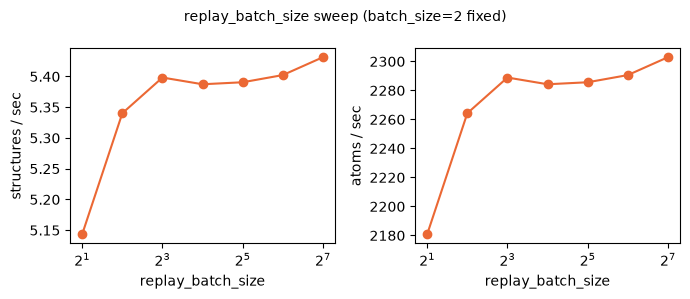

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(7., 3.), sharex=True)

sub = replay_sweep.sort_values('replay_batch_size')
axs[0].plot(sub['replay_batch_size'], sub['structures_per_sec'], marker='o', color=ORANGE)
axs[1].plot(sub['replay_batch_size'], sub['atoms_per_sec'], marker='o', color=ORANGE)

axs[0].set_xlabel('replay_batch_size')
axs[0].set_ylabel('structures / sec')
axs[1].set_xlabel('replay_batch_size')
axs[1].set_ylabel('atoms / sec')
axs[0].set_xscale('log', base=2)
fixed_batch_bs = int(replay_sweep['batch_size'].iloc[0])
fig.suptitle(f'replay_batch_size sweep (batch_size={fixed_batch_bs} fixed)', fontsize=10)
fig.tight_layout()

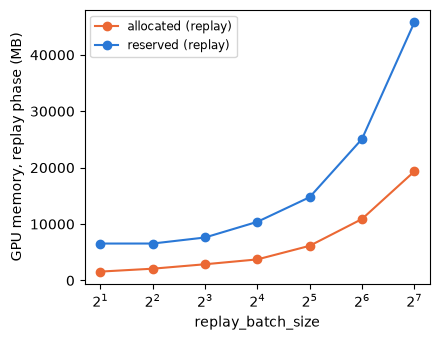

In [10]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))

sub = replay_sweep.sort_values('replay_batch_size')
ax.plot(sub['replay_batch_size'], sub['peak_gpu_mb_replay'], marker='o', color=ORANGE, label='allocated (replay)')
ax.plot(sub['replay_batch_size'], sub['reserved_gpu_mb_replay'], marker='o', color=BLUE, label='reserved (replay)')

ax.set_xlabel('replay_batch_size')
ax.set_ylabel('GPU memory, replay phase (MB)')
ax.set_xscale('log', base=2)
ax.legend(fontsize='small')
fig.tight_layout()

In [11]:
for name, df, x in [('batch_size sweep', batch_sweep, 'batch_size'), ('replay_batch_size sweep', replay_sweep, 'replay_batch_size')]:
    lo, hi = df['sec_per_epoch'].min(), df['sec_per_epoch'].max()
    spread_pct = (hi - lo) / df['sec_per_epoch'].mean() * 100
    print(f'{name}: sec_per_epoch ranges {lo:.1f}-{hi:.1f}s across {df[x].min():.0f}x-{df[x].max():.0f}x '
          f'{x} ({spread_pct:.1f}% spread)')

batch_size sweep: sec_per_epoch ranges 146.2-150.1s across 2x-16x batch_size (2.6% spread)
replay_batch_size sweep: sec_per_epoch ranges 147.3-155.5s across 2x-128x replay_batch_size (5.5% spread)


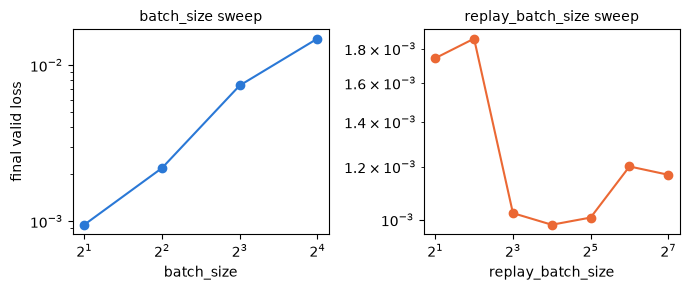

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(7., 3.))

sub = batch_sweep.sort_values('batch_size')
axs[0].plot(sub['batch_size'], sub['final_valid_loss'], marker='o', color=BLUE)
axs[0].set_xlabel('batch_size')
axs[0].set_title('batch_size sweep', fontsize=10)

sub = replay_sweep.sort_values('replay_batch_size')
axs[1].plot(sub['replay_batch_size'], sub['final_valid_loss'], marker='o', color=ORANGE)
axs[1].set_xlabel('replay_batch_size')
axs[1].set_title('replay_batch_size sweep', fontsize=10)

for ax in axs:
    ax.set_yscale('log')
    ax.set_xscale('log', base=2)
axs[0].set_ylabel('final valid loss')
fig.tight_layout()